# Customer Churn Analysis

## Business Understanding

### Problem Statement

Customer churn refers to the loss of customers who discontinue their relationship with a company. In the highly competitive telecommunications industry, retaining existing customers is often more cost-effective than acquiring new ones. Therefore, understanding the factors that contribute to customer churn is essential for improving customer retention and maintaining long-term profitability.

This project analyzes customer demographic information, account details, subscribed services, and billing characteristics to identify the key drivers of churn and develop a predictive model capable of identifying customers at risk of leaving the company.

### Business Objective

The primary business objective is to reduce customer churn by identifying customers who are likely to leave and understanding the factors influencing their decision. By leveraging historical customer data, the company can implement targeted retention strategies and improve customer satisfaction.

Specifically, this project aims to:

* Identify the key factors associated with customer churn.
* Understand how customer demographics, service usage, contract type, and billing characteristics affect retention.
* Build a machine learning model capable of predicting customer churn.
* Provide actionable business recommendations to improve customer retention and customer lifetime value.

## Executive Summary

This notebook investigates customer churn in a telecommunications company and identifies the factors most strongly associated with customer attrition.

### Key Questions
1. What is the overall churn rate?
2. Which customer segments are most likely to churn?
3. How do tenure, contract type, and charges influence churn?
4. What actions could reduce churn and improve retention?

### Deliverables
- Data quality assessment
- Exploratory data analysis
- Churn-driver identification
- Business recommendations

## Dataset Information
[Telco Customer Churn Dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

Number of Rows: 7,043

Target Variable:
- Churn (Yes/No)

Key Features:
- Tenure
- Contract Type
- Monthly Charges
- Total Charges
- Internet Service

# 📊 Notebook 1 — Exploratory Data Analysis (EDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid',palette='muted')
plt.rcParams['figure.dpi']=120

pd.set_option('display.max_columns',None)


In [2]:

df=pd.read_csv('Telco-Customer-Churn.csv')
print("Shape :",df.shape)
df.head()

Shape : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Basic Info & Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


**Missing Values**

In [4]:
print("Missing values after fixing data type:")
df.isnull().sum()

Missing values after fixing data type:


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [5]:
df.loc[df['TotalCharges'].isna(), ['customerID', 'tenure','MonthlyCharges', 'TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [6]:
missing_pct = df['TotalCharges'].isna().mean() * 100
print(f"{missing_pct:.2f}%")

0.16%


In [7]:
df[df['tenure']==0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
df = df.dropna(subset=['TotalCharges'])

#### Note :
The TotalCharges column contained 11 missing values (0.16% of the dataset). After investigation, these records corresponded to customers with zero tenure. Since the number of affected records are negligible, we removed them from the dataset.

**Checking Duplicates**

In [9]:
df.duplicated().sum()

0

**Numerical Features Description**

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### *Saving Cleaned Dataset*

In [15]:
df.to_csv("cleaned_customer_churn.csv")

## 2. Target Variable Distribution

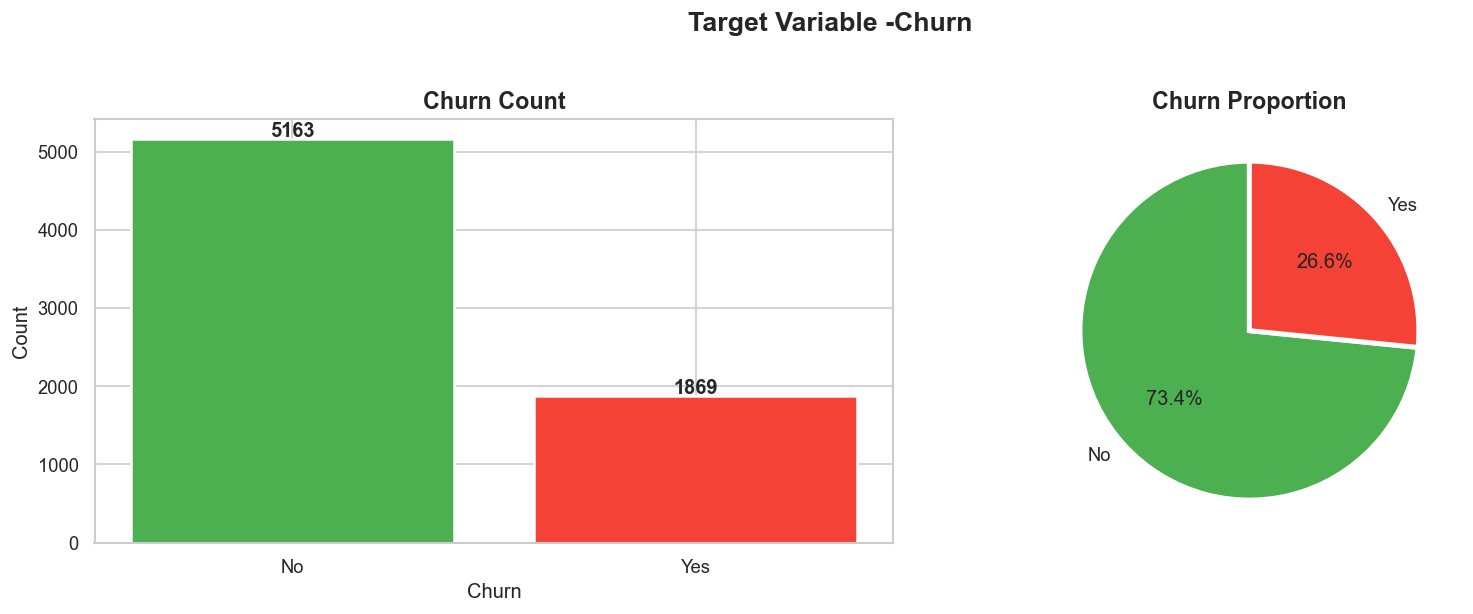


Churn Rate:26.6% | Imbalanced dataset -needs special handling


In [12]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].bar(churn_counts.index,churn_counts.values,
            color=['#4CAF50', '#F44336'],edgecolor='white',linewidth=1.5)
axes[0].set_title("Churn Count",fontsize=14,fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel("Count")
for i,v in enumerate(churn_counts.values):
    axes[0].text(i,v+30,str(v),ha='center',fontweight='bold')

axes[1].pie(churn_pct,labels=churn_pct.index,autopct='%1.1f%%',colors=['#4CAF50', '#F44336'],
            startangle=90,wedgeprops={'edgecolor':'white','linewidth':3})
axes[1].set_title('Churn Proportion',fontsize=14,fontweight='bold')
plt.suptitle('Target Variable -Churn',fontsize=16,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('eda_churn_distribution.png',bbox_inches='tight')
plt.show()
print(f"\nChurn Rate:{churn_pct['Yes']:.1f}% | Imbalanced dataset -needs special handling")


### Key Insights from Target Variable Analysis

* **The dataset exhibits a moderate class imbalance.** Approximately 73.4% of customers are retained, while 26.6% have churned.
* **The churn rate is high enough to warrant predictive modeling.** A churn rate of 26.6% indicates a significant opportunity for the company to identify at-risk customers and implement targeted retention strategies.
* **Class imbalance should be considered during model development.** Since the target classes are not perfectly balanced, evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC should be prioritized alongside Accuracy to ensure reliable model performance.

## 3. Categorical Feature Analysis

In [13]:
categorical_cols = list(df.select_dtypes(include='object').columns)
categorical_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

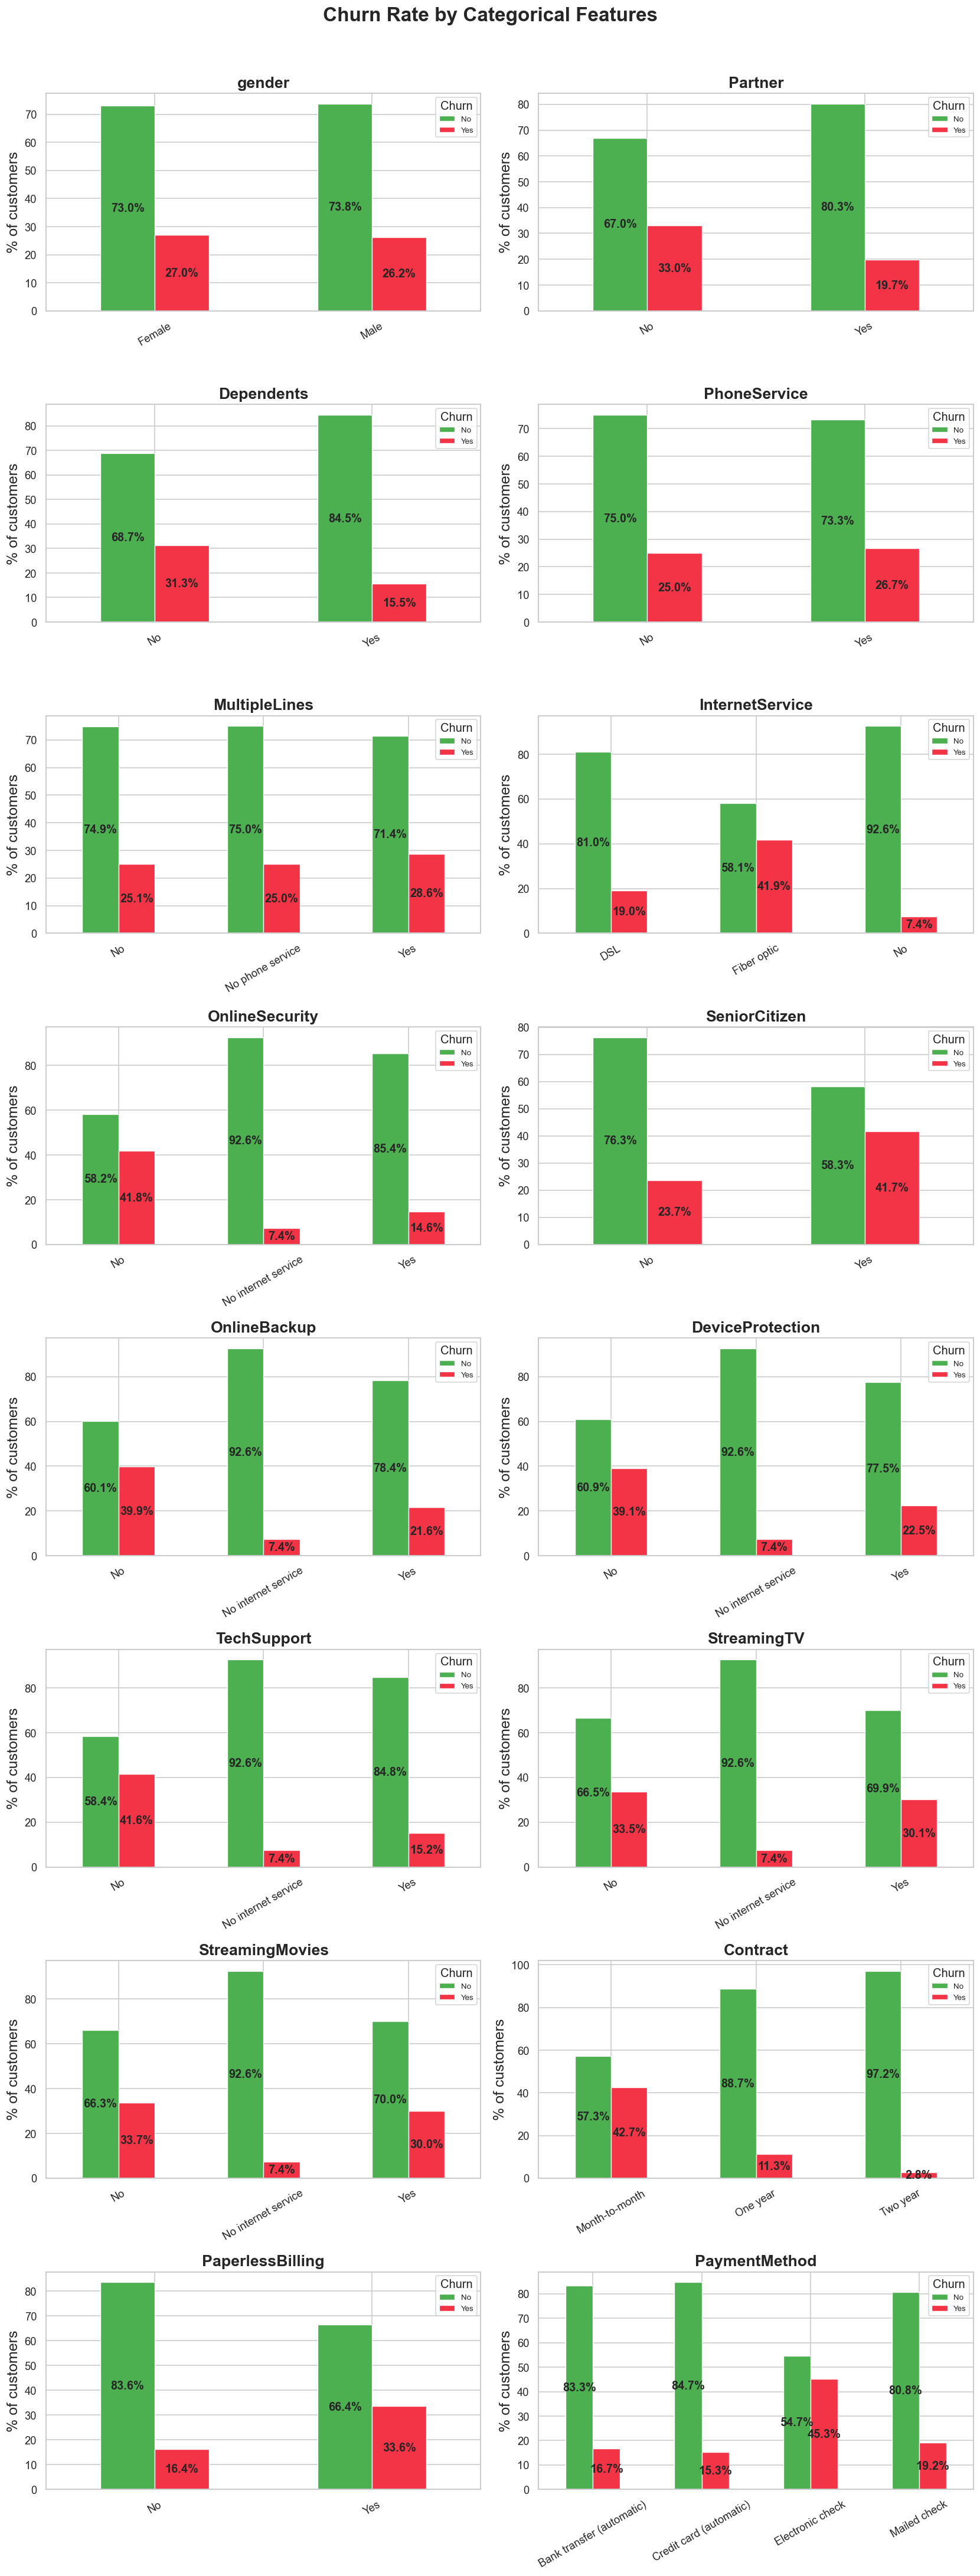

In [14]:

cat_cols = ['gender','Partner','Dependents','PhoneService',
     'MultipleLines','InternetService','OnlineSecurity','SeniorCitizen',
     'OnlineBackup','DeviceProtection','TechSupport','StreamingTV',
    'StreamingMovies','Contract','PaperlessBilling','PaymentMethod']


df_plot = df.copy()
df_plot['SeniorCitizen'] = df_plot['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

fig, axes = plt.subplots(8, 2, figsize=(14, 36))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df_plot.groupby([col, 'Churn']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F33446'],
                edgecolor='white', linewidth=0.8)
    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            fmt='%.1f%%',
            fontsize=12,
            fontweight='bold',
            label_type='center'
        )
    axes[i].set_title(col, fontsize=16, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% of customers',fontsize=15)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Churn', labels=['No', 'Yes'], fontsize=8)
    
    
plt.suptitle('Churn Rate by Categorical Features', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_categorical_features.png', bbox_inches='tight')
plt.show()


### Key Insights from Categorical Features

* **Gender has little impact on customer churn.** Male and female customers exhibit nearly identical churn rates (~26–27%), suggesting that gender is not a strong predictor of churn.

* **Customers without partners or dependents are more likely to churn.** Customers without a partner have a churn rate of 33.0%, compared to 19.7% for those with partners. Similarly, customers without dependents have a churn rate of 31.3%, which is approximately double that of customers with dependents (15.5%).

* **Internet service type is strongly associated with churn.** Customers using Fiber Optic internet show the highest churn rate (41.9%), compared to 19.0% for DSL customers. Customers without internet service have the lowest churn rate (7.4%).

* **Lack of security and support services significantly increases churn risk.** Customers who do not subscribe to Online Security, Online Backup, Device Protection, or Tech Support consistently exhibit much higher churn rates than customers who use these services. For example, customers without Tech Support have a churn rate of 41.6%, compared to 15.2% for those with Tech Support.

* **Senior citizens are more likely to churn.** The churn rate among senior citizens (41.7%) is substantially higher than that of non-senior customers (23.7%).

* **Contract type is one of the strongest predictors of churn.** Customers on month-to-month contracts have the highest churn rate (42.7%), while customers with one-year (11.3%) and two-year (2.8%) contracts are significantly more likely to remain with the company.

* **Paperless billing is associated with higher churn.** Customers using paperless billing have a churn rate of 33.6%, compared to 16.4% among customers who do not use paperless billing.

* **Payment method influences churn behavior.** Customers paying via electronic check exhibit the highest churn rate (45.3%), whereas customers using automatic payment methods (bank transfer or credit card) have much lower churn rates (approximately 15–17%).

* **Phone service and multiple lines have minimal impact on churn.** The churn rates across these categories are relatively similar, indicating limited predictive power.

## 4. Numerical Feature Distributions

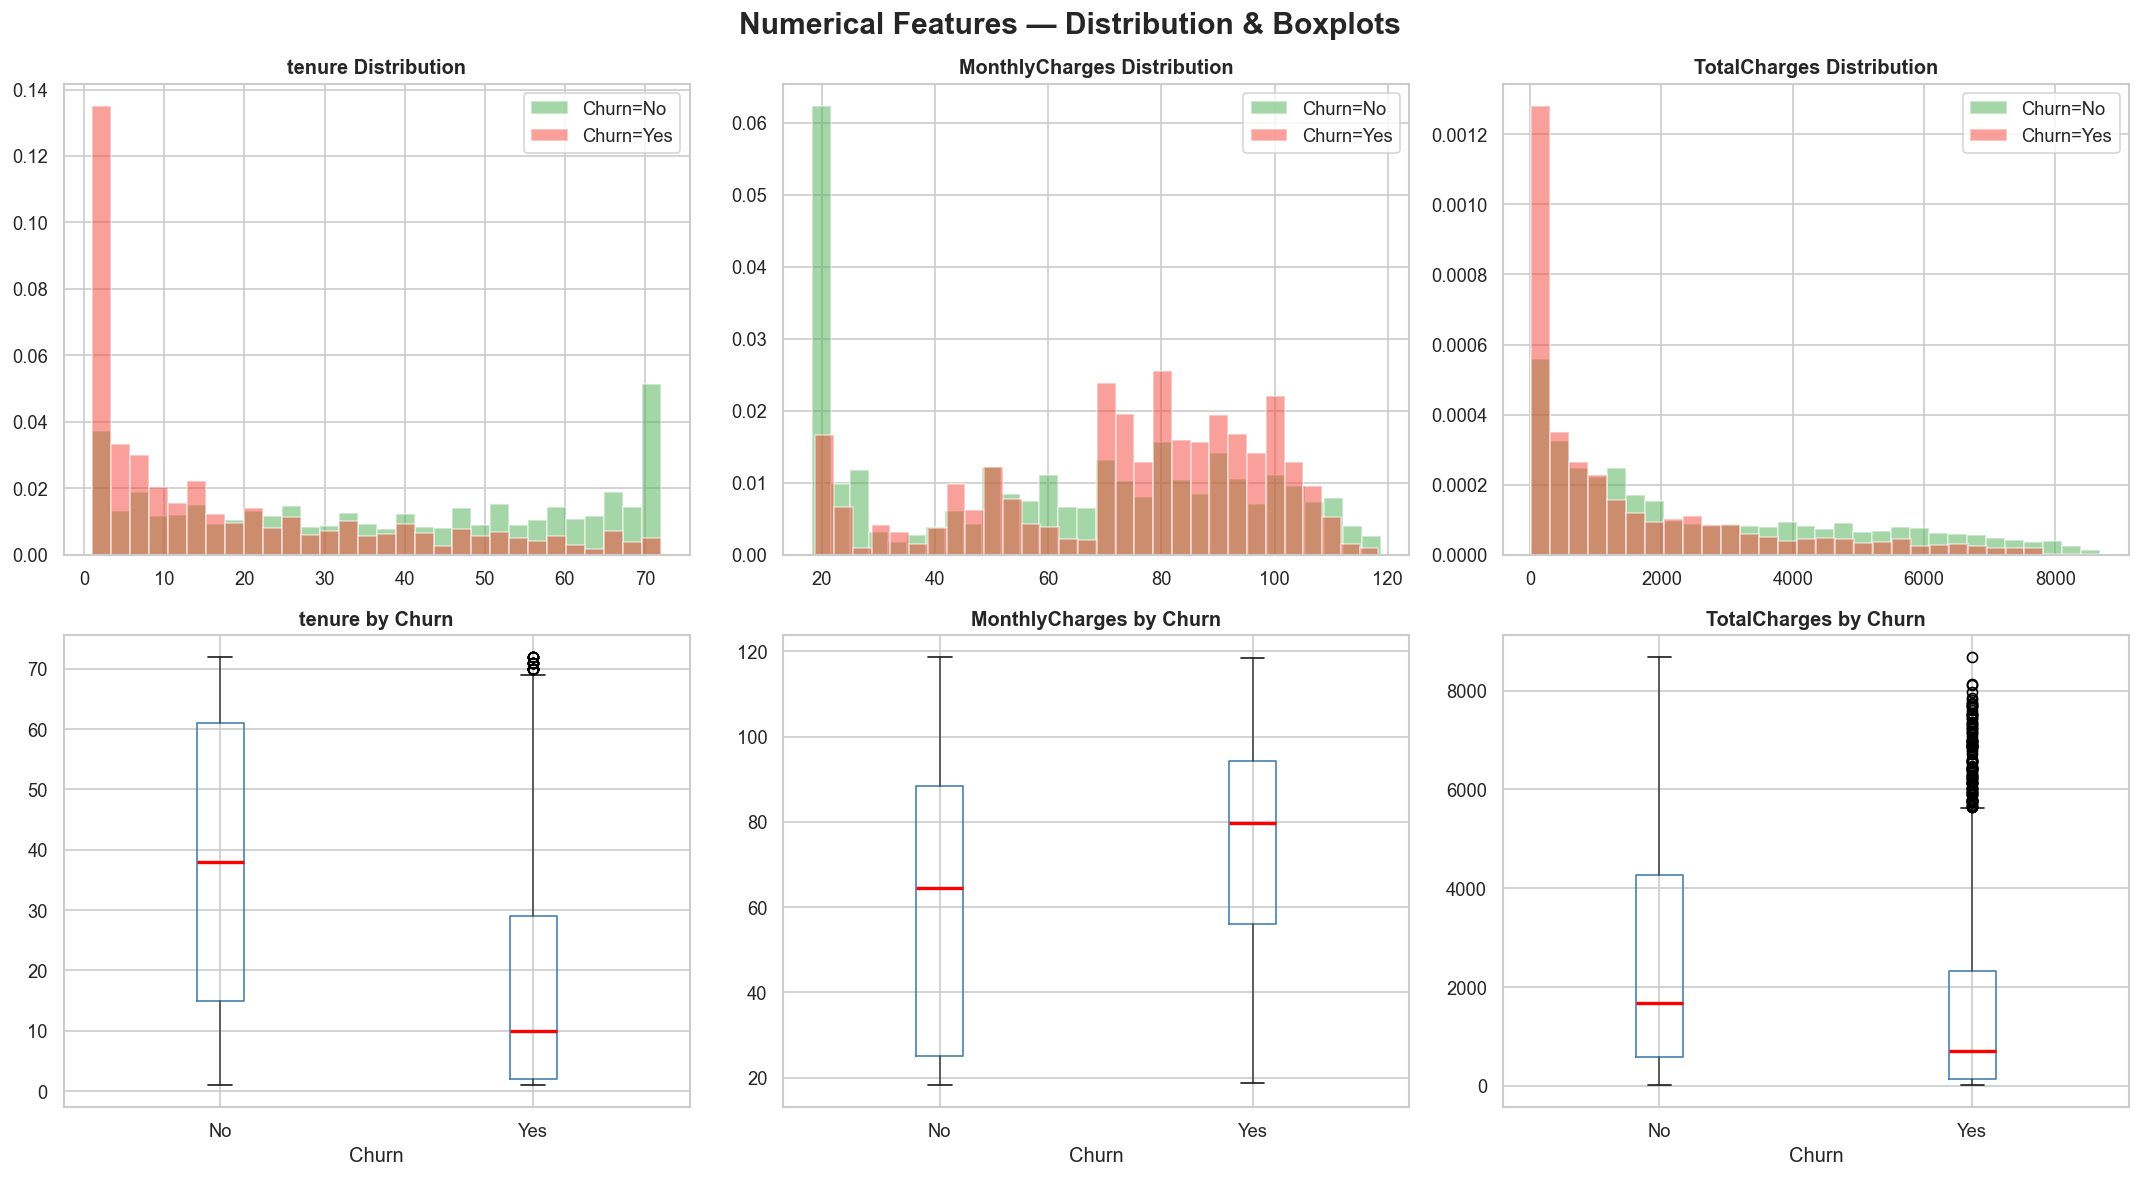

In [15]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(num_cols):
    # KDE by churn
    for churn_val, color in [('No', '#4CAF50'), ('Yes', '#F44336')]:
        subset = df[df['Churn'] == churn_val][col].dropna()
        axes[0, i].hist(subset, bins=30, alpha=0.5, color=color, label=f'Churn={churn_val}', density=True)
    axes[0, i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[0, i].legend()

    # Boxplot
    df.boxplot(column=col, by='Churn', ax=axes[1, i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col} by Churn', fontsize=12, fontweight='bold')
    axes[1, i].set_xlabel('Churn')

plt.suptitle('Numerical Features — Distribution & Boxplots', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_numerical_features.png', bbox_inches='tight')
plt.show()

### Key Insights from Numerical Features

* **Tenure is strongly associated with customer churn.** Customers who churn have significantly lower tenure, with most churn occurring within the first 12 months. In contrast, retained customers tend to have much longer tenures, indicating that customer loyalty increases over time.

* **Customers with higher monthly charges are more likely to churn.** The distribution and boxplot show that churned customers generally pay higher monthly fees than retained customers, suggesting that pricing or perceived value may influence churn decisions.


* **Total charges are lower among churned customers.** Since churned customers typically have shorter tenures, they accumulate lower total charges before leaving. Retained customers generate substantially higher lifetime revenue due to their longer relationship with the company.


### *Business Implication:*
The company should focus on improving customer onboarding and engagement during the early months of the customer lifecycle, as the highest churn risk is concentrated among newer customers. Additionally, the relationship between high monthly charges and churn should be investigated to ensure customers perceive sufficient value for the price they pay.

## 5. Tenure Groups

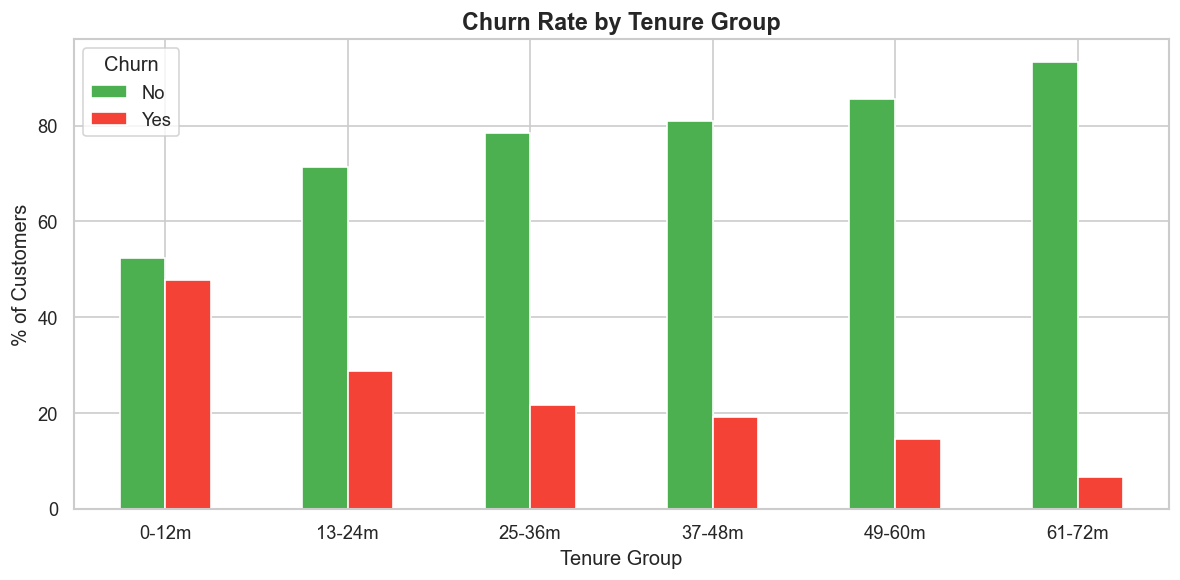

Key Insight: New customers (0-12 months) have the HIGHEST churn rate!


In [10]:

df['TenureGroup'] = pd.cut(df['tenure'],
                            bins=[0, 12, 24,36,48, 60, 72],
                            labels=['0-12m', '13-24m', '25-36m','37-48m', '49-60m', '61-72m'])

ct = df.groupby(['TenureGroup', 'Churn']).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ct_pct.plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'], edgecolor='white')
ax.set_title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('% of Customers')
ax.legend(title='Churn', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_tenure_groups.png', bbox_inches='tight')
plt.show()
print("Key Insight: New customers (0-12 months) have the HIGHEST churn rate!")


### Key Insights from Tenure Group Analysis

* **Customer churn is highest during the first year of service.** Customers with a tenure of 0–12 months exhibit the highest churn rate (~47%), indicating that nearly half of new customers leave within their first year.
* **Churn decreases consistently as customer tenure increases.** The churn rate drops from 47.8% in the first year to 28.8% for customers with 13–24 months of tenure and continues to decline across all subsequent tenure groups.
  
* **Long-term customers demonstrate strong loyalty.** Customers with more than 60 months of tenure have a churn rate of only 6.7%, while over 93% remain with the company.


### *Business Implication*
Customer retention initiatives should focus primarily on new customers, particularly during their first year of service.
Improving onboarding, customer support, and engagement during the early stages of the customer lifecycle could significantly reduce churn.

## 6. Contract Type vs Churn — Key Driver

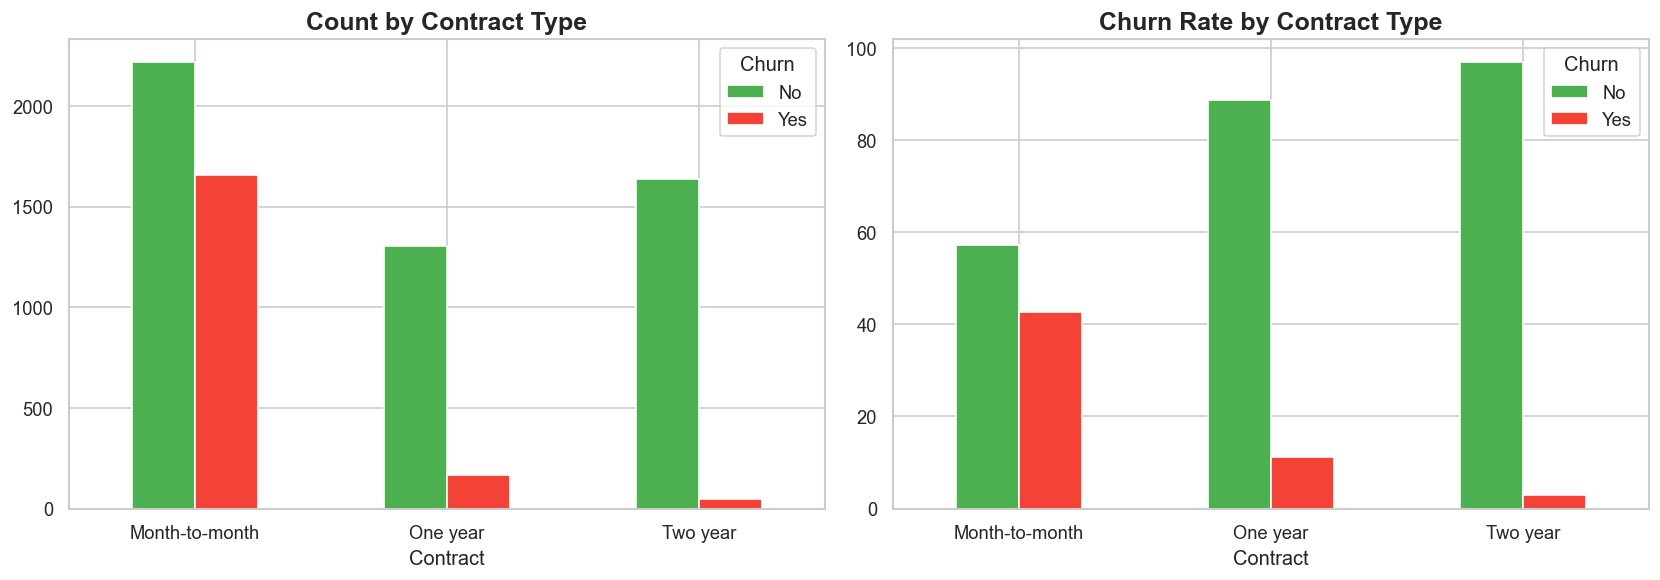

Month-to-month            → Churn rate: 42.71%
One year                  → Churn rate: 11.28%
Two year                  → Churn rate: 2.85%


In [11]:

ct = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ct.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'], edgecolor='white')
axes[0].set_title('Count by Contract Type', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Contract')
axes[0].tick_params(axis='x', rotation=0)

ct_pct.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#F44336'], edgecolor='white')
axes[1].set_title('Churn Rate by Contract Type', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Contract')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_contract_churn.png', bbox_inches='tight')
plt.show()

for contract in df['Contract'].unique():
    rate = df[df['Contract']==contract]['Churn'].eq('Yes').mean()*100
    print(f"{contract:25s} → Churn rate: {rate:.2f}%")


### Key Insights from Contract Type Analysis

* **Month-to-month customers exhibit the highest churn rate.** Approximately 42.7% of customers on month-to-month contracts churn, making them the most vulnerable customer segment.

* **Longer contract durations significantly improve retention.** Customers on one-year contracts have a churn rate of only 11.3%, while those on two-year contracts have an exceptionally low churn rate of 2.8%.
* **The majority of churned customers belong to the month-to-month segment.** The count plot shows that most customers who leave the company are enrolled in month-to-month contracts, highlighting this group as the primary driver of overall churn.

* **Customer commitment increases as contract length increases.** The steady decline in churn from month-to-month → one-year → two-year contracts suggests that customers who commit to longer agreements are substantially less likely to switch providers.

## 7. Correlation Heatmap (Numerical)

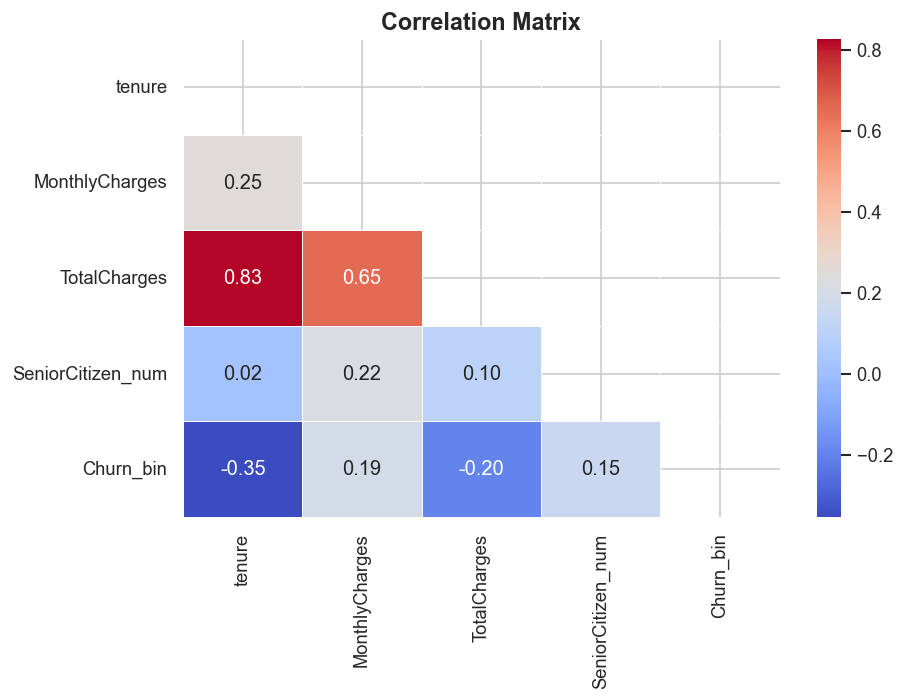

In [12]:

df_corr = df.copy()
df_corr['Churn_bin'] = (df_corr['Churn'] == 'Yes').astype(int)
df_corr['SeniorCitizen_num'] = df_corr['SeniorCitizen']

corr = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges',
                  'SeniorCitizen_num', 'Churn_bin']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',mask=mask,ax=ax,linewidths=0.5)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()


### Key Insights from the Correlation Matrix

* **Tenure has the strongest relationship with churn among the numerical features.** The correlation between tenure and churn is -0.35, indicating that customers with longer tenure are less likely to churn.  
* **Total Charges are moderately negatively correlated with churn (-0.20).** Customers who have accumulated higher total charges tend to remain with the company longer, which is consistent with the tenure analysis.
  
* **Monthly Charges show a weak positive correlation with churn (0.19).** Customers paying higher monthly fees are slightly more likely to churn, suggesting that pricing may influence customer retention.
* **Senior Citizen status has a weak positive correlation with churn (0.15).** Although the relationship is not strong, senior citizens are somewhat more likely to leave compared to non-senior customers.
* **Tenure and Total Charges exhibit a strong positive correlation (0.83).** This is expected because customers who stay longer naturally accumulate higher total charges over time.
Monthly Charges and Total Charges show a moderate positive correlation (0.65). Customers paying higher monthly fees generally accumulate larger total charges.

* **Multicollinearity concerns are observed among the features used for modeling.** "A strong positive correlation (r ≈ 0.83) was observed between Tenure and TotalCharges, indicating potential multicollinearity. Further assessment using VIF is recommended before model development."


## 8. Monthly Charges vs Tenure (Scatter)

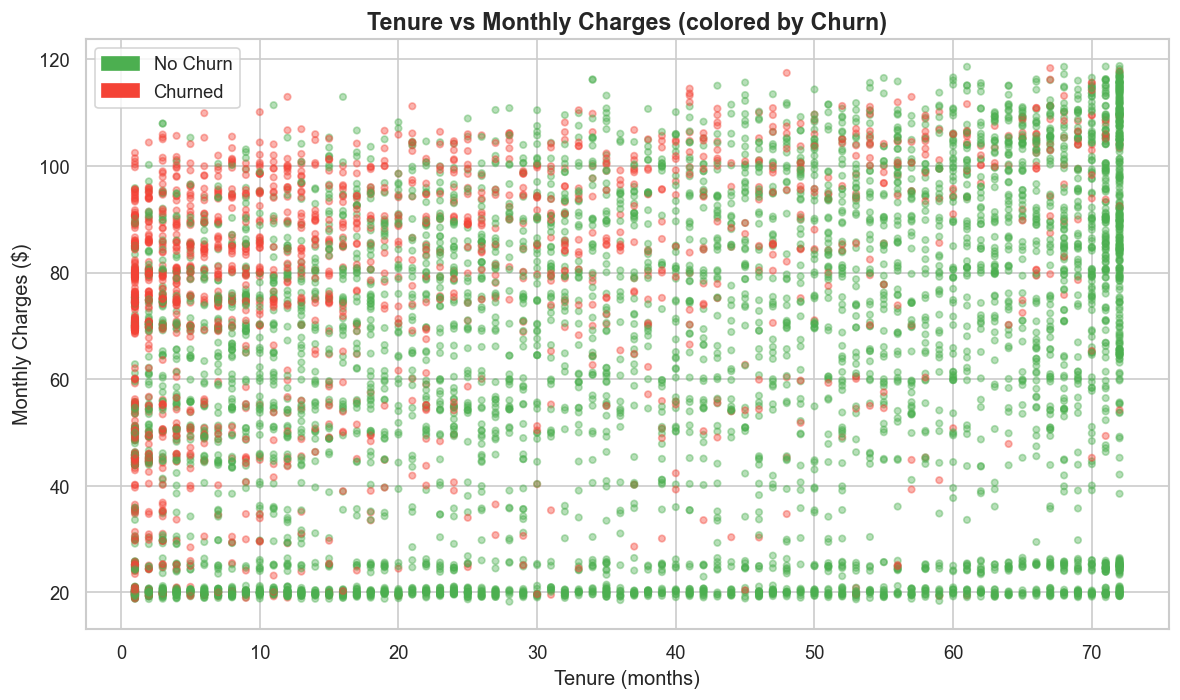

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = df['Churn'].map({'No': '#4CAF50', 'Yes': '#F44336'})
scatter = ax.scatter(df['tenure'], df['MonthlyCharges'],
                     c=colors, alpha=0.4, s=15)
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
ax.set_title('Tenure vs Monthly Charges (colored by Churn)', fontsize=14, fontweight='bold')
from matplotlib.patches import Patch
legend = [Patch(color='#4CAF50', label='No Churn'),
          Patch(color='#F44336', label='Churned')]
ax.legend(handles=legend)
plt.tight_layout()
plt.savefig('eda_scatter_tenure_charges.png', bbox_inches='tight')
plt.show()

### Key Insights from Tenure vs Monthly Charges Analysis

* **Customers with short tenure are more likely to churn.** The majority of churned customers (red points) are concentrated in the lower tenure range, particularly within the first 24 months.
* **High monthly charges combined with low tenure are associated with the highest churn risk.** A dense cluster of churned customers is visible among customers with monthly charges above approximately $70 and relatively short tenures.
* **Long-tenured customers are more likely to remain with the company regardless of monthly charges.** Even customers paying high monthly fees tend to stay when they have been with the company for many years.
* **Monthly charges alone do not fully explain churn.** Churned and retained customers appear across nearly all monthly charge levels, indicating that monthly charges should be analyzed together with other factors such as tenure and contract type.


**Total Charges vs Tenure (Scatter)**

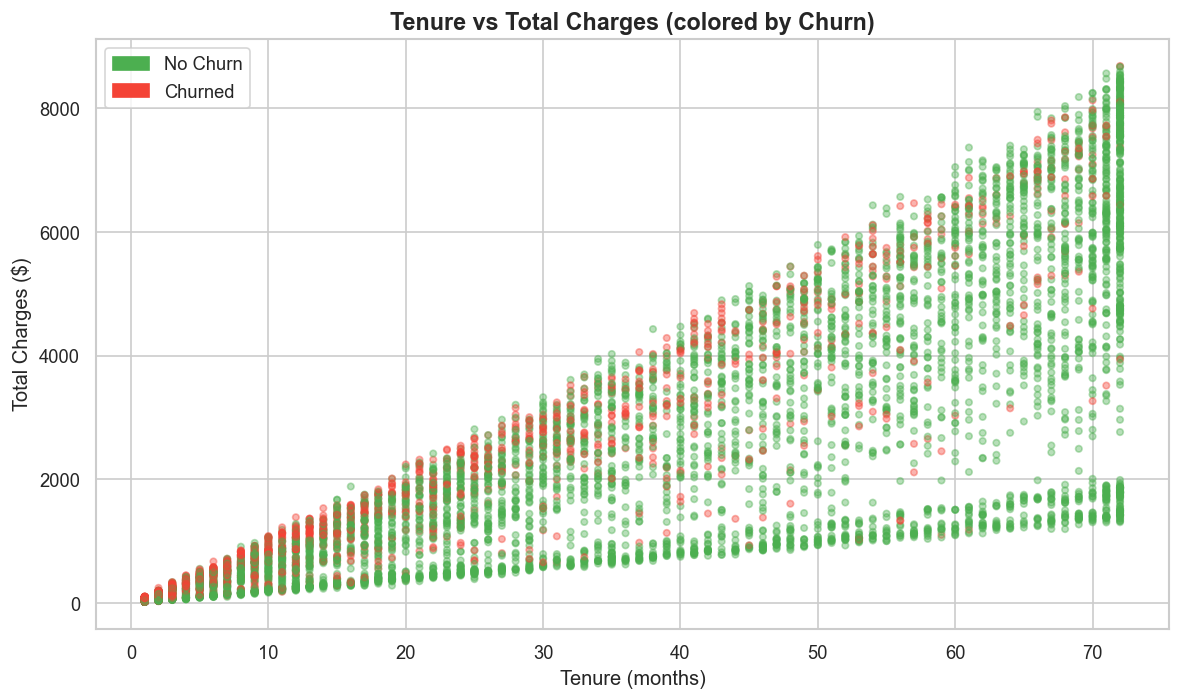

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = df['Churn'].map({'No': '#4CAF50', 'Yes': '#F44336'})
scatter = ax.scatter(df['tenure'], df['TotalCharges'],
                     c=colors, alpha=0.4, s=15)
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Total Charges ($)', fontsize=12)
ax.set_title('Tenure vs Total Charges (colored by Churn)', fontsize=14, fontweight='bold')
from matplotlib.patches import Patch
legend = [Patch(color='#4CAF50', label='No Churn'),
          Patch(color='#F44336', label='Churned')]
ax.legend(handles=legend)
plt.savefig('eda_scatter_tenure_vs_totalcharges.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

### Key Insights from Tenure vs Total Charges Analysis

* **There is a strong positive relationship between tenure and total charges.** As customer tenure increases, total charges increase almost linearly, indicating that customers accumulate revenue over time.
* **Most churned customers are concentrated in the lower tenure range.** The majority of churned customers (red points) appear within the first 36 months, reinforcing the finding that new customers are more likely to leave the company.
  
* **Long-tenured customers exhibit low churn despite high accumulated spending.** Even among customers with total charges exceeding $5,000, the overwhelming majority are retained customers, indicating strong customer commitment.


## 9. Key EDA Insights Summary

In [30]:

insights = {
    "Overall Churn Rate":           "26.5% — imbalanced dataset",
    "Contract Type":                "Month-to-month customers churn ~42% vs 11% (one year) vs 3% (two year)",
    "Tenure":                       "Customers in first 12 months are at highest churn risk",
    "Monthly Charges":              "Churners pay higher monthly charges on average",
    "Internet Service":             "Fiber optic customers churn more than DSL",
    "Online Security/TechSupport":"No security/support → significantly higher churn",
    "Senior Citizens":              "Senior citizens have ~41% churn vs ~24% for non-seniors",
    "Paperless Billing":            "Paperless billing users churn more (~33%)",
    "Payment Method":               "Customers paying via electronic check churn more (~45%)",
}

print("=" * 65)
print("       KEY EDA INSIGHTS — Telecom Churn")
print("=" * 65)
for k, v in insights.items():
    print(f"  ► {k:<30} {v}")
print("=" * 65)


       KEY EDA INSIGHTS — Telecom Churn
  ► Overall Churn Rate             26.5% — imbalanced dataset
  ► Contract Type                  Month-to-month customers churn ~42% vs 11% (one year) vs 3% (two year)
  ► Tenure                         Customers in first 12 months are at highest churn risk
  ► Monthly Charges                Churners pay higher monthly charges on average
  ► Internet Service               Fiber optic customers churn more than DSL
  ► Online Security/TechSupport    No security/support → significantly higher churn
  ► Senior Citizens                Senior citizens have ~41% churn vs ~24% for non-seniors
  ► Paperless Billing              Paperless billing users churn more (~33%)
  ► Payment Method                 Customers paying with electronic check churn more (~45%)


## 10. Business Implications


The exploratory data analysis reveals several key drivers of customer churn and highlights opportunities for improving customer retention.

### 1. Focus on Early Customer Retention

The analysis shows that churn is heavily concentrated among customers with low tenure, particularly within the first 12–24 months. Customers who remain beyond this period become significantly less likely to leave.

**Recommendation:**

* Improve customer onboarding programs.
* Conduct proactive follow-ups with new customers.
* Offer incentives during the first year of service.
* Monitor customer satisfaction closely during the early lifecycle.
### 2. Reduce Churn Among Month-to-Month Customers

Contract type emerged as one of the strongest predictors of churn. Customers on month-to-month contracts exhibit substantially higher churn rates compared to customers on one-year or two-year contracts.

**Recommendation:**

* Encourage migration to longer-term contracts through discounts and loyalty rewards.
* Develop targeted retention campaigns for month-to-month subscribers.
* Introduce contract renewal incentives before customers reach cancellation risk.

### 3. Investigate Fiber Optic Customer Experience

Customers using Fiber Optic internet service show significantly higher churn rates than customers using DSL or no internet service.

**Recommendation:**

* Investigate potential service quality, pricing, or customer satisfaction issues among Fiber Optic users.
* Conduct customer feedback surveys.
* Evaluate whether pricing aligns with perceived service value.

### 4. Promote Value-Added Services

Customers without Online Security, Tech Support, Online Backup, and Device Protection services are considerably more likely to churn.

**Recommendation:**

* Bundle value-added services into subscription packages.
* Educate customers about the benefits of these services.
* Offer free trials to increase adoption.

### 5. Identify High-Risk Customer Segments

Several customer groups demonstrate elevated churn risk:

* Senior citizens
* Customers without partners or dependents
* Customers using electronic check payments
* Customers with high monthly charges

**Recommendation:**

* Develop personalized retention strategies for these segments.
* Provide targeted offers and customer support initiatives.
* Implement churn monitoring for high-risk groups.

### 6. Increase Customer Lifetime Value Through Retention

The analysis shows a strong relationship between tenure and total charges, indicating that long-term customers generate significantly more revenue over time.

**Recommendation:**

* Prioritize retention over acquisition when possible.
* Invest in loyalty programs for existing customers.
* Focus on extending customer lifespan to maximize lifetime value.

## Final Business Conclusion

>Customer churn is primarily driven by short customer tenure, month-to-month contracts, Fiber Optic internet service, lack of value-added services, and higher monthly charges. The findings suggest that the most effective retention strategy would be to improve early customer engagement, encourage long-term contracts, increase adoption of support and security services, and proactively target high-risk customer segments. Successfully reducing churn among these groups could significantly improve customer lifetime value, revenue stability, and overall business performance.